Dong Woon Kim, M.D.  
BRUIN ID: 21399491  

Bellevue University  
Masters in Data Science  
DSC 550 Data Mining  

**Assignment Instructions**:

You will build a model with the movie reviews dataset that you worked with in Week 3: [Bag of Words Meets Bags of Popcorn](https://www.kaggle.com/c/word2vec-nlp-tutorial/data). 

1. Get the stemmed data using the same process you did in Week 3.
2. Split this into a training and test set.
3. Fit and apply the tf-idf vectorization to the training set.
4. Apply but DO NOT FIT the tf-idf vectorization to the test set (Why?).
5. Train a logistic regression using the training data.
6. Find the model accuracy on test set.
7. Create a confusion matrix for the test set predictions.
8. Get the precision, recall, and F1-score for the test set predictions.
9. Create a ROC curve for the test set.
10. Pick another classification model you learned about this week and repeat steps (5) – (9).

In [44]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score, 
    recall_score, 
    f1_score, 
    roc_curve, 
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.naive_bayes import MultinomialNB

**1**. Get the stemmed data using the same process you did in Week 3.

In [45]:
import pandas as pd
df = pd.read_csv("./data/labeled_train_data.csv", encoding = "utf-8")
df = df.drop(columns = ["Unnamed: 0"], errors = "ignore").copy()
df.head()

,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


In [46]:
stemmer = PorterStemmer()
stop_words = set(ENGLISH_STOP_WORDS)

def stem_review(review):
    words = re.sub(r"[^a-zA-Z]", " ", str(review).lower()).split()
    return " ".join(stemmer.stem(word) for word in words if word not in stop_words)

df["stemmed_review"] = df["review"].apply(stem_review)

In [47]:
df.to_csv("./data/stemmed_data.csv", encoding = "utf-8")

In [48]:
df = pd.read_csv("./data/stemmed_data.csv", encoding = "utf-8")

**2**. Split this into a training and test set.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    df["stemmed_review"], 
    df["sentiment"],
    test_size=0.2, 
    random_state=42, 
    stratify=df["sentiment"]
)

**3**. Fit and apply the tf-idf vectorization to the training set.

In [21]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)

**4.** Apply but DO NOT FIT the tf-idf vectorization to the test set (Why?).

Fitting the tf-idf vectorization to the test set would leak vocabulary and document-frequency information from unseen reviews into model development. 

Therefore, you should only fit on the training data because fitting learns the vocabulary and IDF weights. If you fit on the test data, the model gains information from data it is supposed to be evaluated on, causing data leakage and an unrealistically optimistic accuracy.

In [23]:
X_test_tfidf = tfidf.transform(X_test) 

**5**. Train a logistic regression using the training data.

In [24]:
lr = LogisticRegression(max_iter = 1000)

lr.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

**6**. Find the model accuracy on test set.

In [31]:
from IPython.display import HTML
y_pred = lr.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8824


**7**. Create a confusion matrix for the test set predictions.

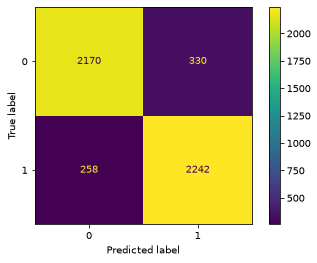

In [35]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

plt.show()

**8**. Get the precision, recall, and F1-score for the test set predictions.

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2500
           1       0.87      0.90      0.88      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



**9**. Create a ROC curve for the test set.

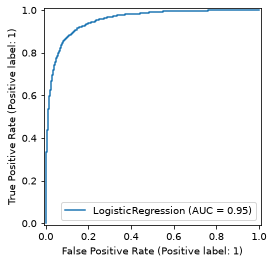

In [40]:
RocCurveDisplay.from_estimator(lr, X_test_tfidf, y_test)
plt.show()

**10**. Pick another classification model you learned about this week and repeat steps (5) – (9).

Accuracy: 0.8598


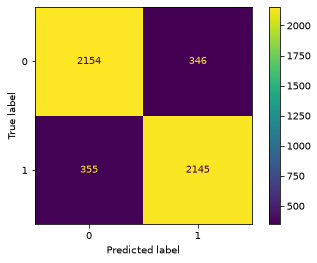

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      2500
           1       0.86      0.86      0.86      2500

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



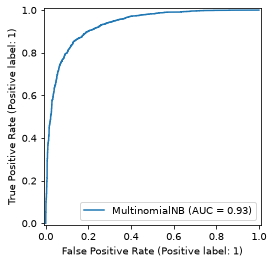

In [43]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()

# 5
nb.fit(X_train_tfidf, y_train)

# 6
y_pred_nb = nb.predict(X_test_tfidf) 
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

# 7 
cm_nb = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(cm_nb).plot()
plt.show()

# 8 
print(classification_report(y_test, y_pred_nb))

# 9
RocCurveDisplay.from_estimator(nb, X_test_tfidf, y_test)
plt.show()